# Is $\alpha=1$ (ordinary CM) optimal? — Pearl-CM $\alpha$ sweep vs $p$

**Where $\alpha$ comes from.** The first-pass MWPM returns the *minimum-weight* set of edges
consistent with the syndrome — its single best guess at the underlying error. But minimum weight is
not the same as *correct*: many distinct physical errors produce the same syndrome (degeneracy), so
MWPM is **not guaranteed to select the edges that actually fired**. When a neighbour edge $\nu$ is
selected in the first pass, that is therefore only *evidence* — not proof — that $\nu$ truly occurred.

Ordinary correlated matching (CM) ignores this caveat: it makes the **hard-evidence** assumption
"MWPM selected $\nu \Rightarrow \nu$ fired" and reweights a correlated neighbour $\mu$ with the
conditional $P(\mu\mid\nu)=P(\mu,\nu)/P(\nu)$. **Pearl's rule of soft (virtual) evidence** instead
treats the selection as uncertain, with a single trust parameter

$$\alpha \;=\; P\big(\nu\ \text{actually fired}\;\big|\;\text{MWPM selected }\nu\big)\in[0,1].$$

The posterior on $\mu$ is then the Jeffrey/Pearl mixture over "$\nu$ fired" vs. "$\nu$ did not fire":

$$P(\mu\mid\text{MWPM selected }\nu)=\alpha\,P(\mu\mid\nu)+(1-\alpha)\,P(\mu\mid\lnot\nu),$$

with $P(\mu\mid\nu)=P(\mu,\nu)/P(\nu)$ and $P(\mu\mid\lnot\nu)=\big(P(\mu)-P(\mu,\nu)\big)/\big(1-P(\nu)\big)$.

So $\alpha=1$ (full trust in MWPM) recovers **exactly ordinary CM**; $\alpha<1$ *softens* the discount
to account for MWPM sometimes selecting the wrong edge; $\alpha>1$ extrapolates to an *even more
aggressive* discount than CM. The question is which $\alpha$ actually minimises the logical error rate.

This notebook fixes **no drift** (mismatch = 1) and, for each physical error rate $p$, decodes the
**same** syndromes with the batched Pearl two-pass decoder (`TwoPassCorrelatedMatching(dem, alpha)`)
across a grid of $\alpha$, then reports the logical error rate (LER) as a function of $\alpha$. If the
LER is minimised at $\alpha=1$ everywhere, CM is already optimal within this family; if the minimum
drifts away from 1 (especially at low $p$), soft/strong evidence helps.

In [9]:
%matplotlib inline
import gc
import os, sys, time, csv
import numpy as np
import matplotlib.pyplot as plt
import pymatching

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "scripts"))

from NeuralCM.syndrome_data_generation import SyndromeDataGenerator
from NeuralCM.two_pass_correlated_matching import TwoPassCorrelatedMatching

CFG = dict(
    distance=7, n_rounds=7, bypass_threshold=2,
    # physical error rates (mismatch = 1, no drift)
    p_values=[5e-4, 7e-4, 5e-3],
    # alpha grid: 0..1 plus a few > 1 (more-aggressive-than-CM extrapolation)
    alpha_grid=[0.4, 0.7, 0.9],
    # per-p sampling: grow shots until CM (alpha=1) hits target_errors, capped at max_shots
    # Keep chunks modest so the sampler never materializes a huge detector matrix at once.
    target_errors=300, max_shots=1000_000_000_000, chunk=50_000, seed=12345,
    out_csv="data/pearl_alpha_sweep_vs_p_d7.csv",
    out_png="plots/pearl_alpha_sweep_vs_p_d7.png",
    out_png_best="plots/pearl_alpha_best_vs_p_d7.png",
)
for d in ("data", "plots"):
    os.makedirs(d, exist_ok=True)
print("repo root:", ROOT)


repo root: c:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC


## 1. Sweep $\alpha$ for every $p$

For each $p$ we sample syndromes (no drift) until the CM baseline accumulates `target_errors`
logical errors (or `max_shots` is reached), then decode that **fixed** syndrome batch with every
$\alpha$ (common random numbers). LER and its binomial std are recorded.

In [ ]:
# Streaming alpha sweep: decode each chunk with every alpha (common random numbers) and
# accumulate per-alpha logical errors -- the syndromes are NEVER stored, so memory stays
# bounded to one chunk no matter how many shots a low-p point needs. CM (alpha=1.0) is always
# evaluated, both as the stopping criterion and as the relative-LER reference, even when it is
# not in the user's alpha grid.
alphas = np.array(CFG["alpha_grid"])
eval_alphas = np.array(sorted(set(CFG["alpha_grid"]) | {1.0}))   # union, deduplicated

rows = []                # (p, alpha, shots, err, ler, std)
ler_grid = {}            # p -> LER over the user's alpha grid
cm_ler = {}              # p -> LER at alpha = 1.0 (true CM reference)
t0 = time.time()

for p in CFG["p_values"]:
    gen = SyndromeDataGenerator(
        distance=CFG["distance"], n_rounds=CFG["n_rounds"], mismatch=1.0,
        noise_model={"version": "built-in",
                     "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p,
                     "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=CFG["chunk"], qec_code="surface_code")
    base_circuit, base_dem, _ = gen.generate_base_circuit()
    dec = TwoPassCorrelatedMatching(base_dem, alpha=1.0, bypass_threshold=CFG["bypass_threshold"])
    sampler = base_circuit.compile_detector_sampler(seed=CFG["seed"])

    err = {float(a): 0 for a in eval_alphas}
    shots = 0
    while shots < CFG["max_shots"]:
        syn, obs = sampler.sample(shots=CFG["chunk"], separate_observables=True)
        obs = obs.flatten()
        for a in eval_alphas:
            dec.alpha = float(a)
            err[float(a)] += int(np.sum(dec.decode_batch(syn)[:, 0] != obs))
        shots += CFG["chunk"]
        del syn, obs
        gc.collect()
        if err[1.0] >= CFG["target_errors"]:
            break

    n = shots
    ler_grid[p] = np.array([err[float(a)] / n for a in CFG["alpha_grid"]])
    cm_ler[p] = err[1.0] / n
    for a in eval_alphas:
        ler = err[float(a)] / n
        std = np.sqrt(ler * (1 - ler) / n)
        rows.append((p, float(a), n, err[float(a)], ler, std))

    jb = int(np.argmin(ler_grid[p]))
    best_a, best_ler, cl = CFG["alpha_grid"][jb], ler_grid[p][jb], cm_ler[p]
    print(f"p={p:.1e} | shots={n:,} | CM(a=1) LER={cl:.3e} | "
          f"best a={best_a:.4g} LER={best_ler:.3e} | "
          f"{'CM optimal' if best_ler >= cl else f'improves {100*(1-best_ler/cl):.1f}%'}")

    del gen, base_circuit, base_dem, dec, sampler
    gc.collect()

print(f"\nswept in {time.time()-t0:.1f}s")

with open(CFG["out_csv"], "w", newline="") as f:
    w = csv.writer(f); w.writerow(["p", "alpha", "shots", "errors", "ler", "ler_std"])
    w.writerows(rows)
print("saved", CFG["out_csv"])


## 2. LER vs $\alpha$ for each $p$

Each curve is normalised by its own CM ($\alpha=1$) LER, so values **below 1.0** mean a given
$\alpha$ beats CM. The vertical line marks $\alpha=1$.

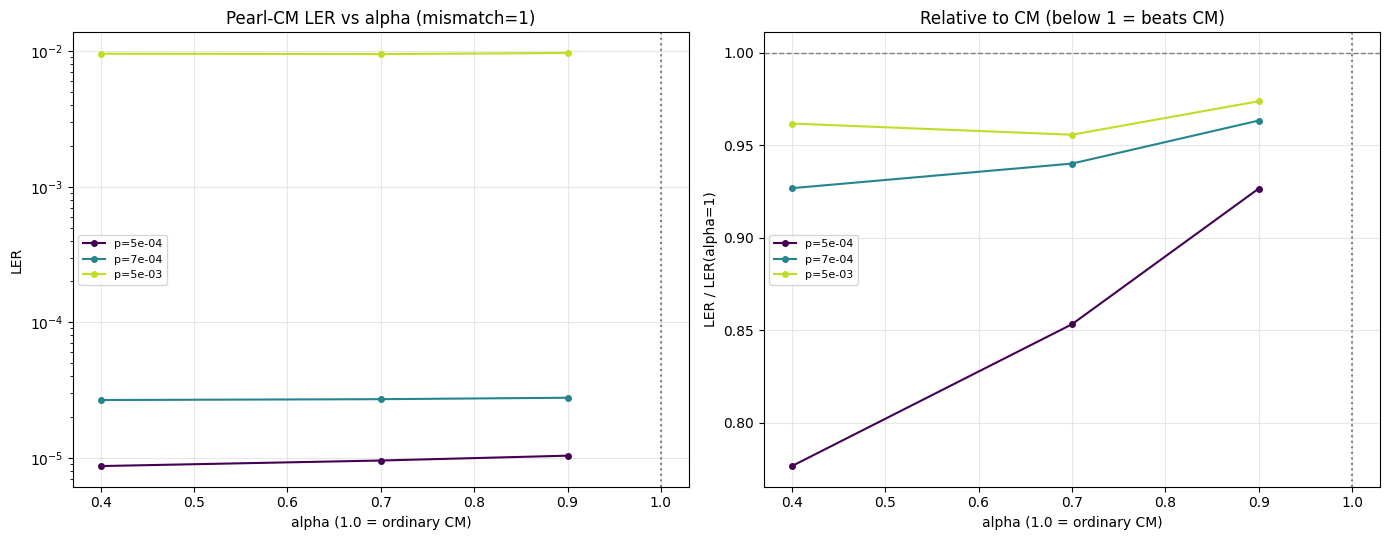

saved plots/pearl_alpha_sweep_vs_p_d7.png


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(CFG["p_values"])))

for p, c in zip(CFG["p_values"], colors):
    lers = ler_grid[p]
    ax[0].plot(alphas, lers, "o-", color=c, ms=4, label=f"p={p:.0e}")
    ax[1].plot(alphas, lers / cm_ler[p], "o-", color=c, ms=4, label=f"p={p:.0e}")

for a in ax:
    a.axvline(1.0, color="gray", ls=":", lw=1.5)
    a.set_xlabel("alpha (1.0 = ordinary CM)"); a.grid(alpha=0.3); a.legend(fontsize=8)
ax[0].set_yscale("log"); ax[0].set_ylabel("LER"); ax[0].set_title("Pearl-CM LER vs alpha (mismatch=1)")
ax[1].axhline(1.0, color="gray", ls="--", lw=1)
ax[1].set_ylabel("LER / LER(alpha=1)"); ax[1].set_title("Relative to CM (below 1 = beats CM)")
fig.tight_layout(); fig.savefig(CFG["out_png"], dpi=200, bbox_inches="tight"); plt.show()
print("saved", CFG["out_png"])

## 3. Best $\alpha$ vs $p$

Where does the LER-minimising $\alpha$ sit relative to 1.0, and how much does it gain over CM?

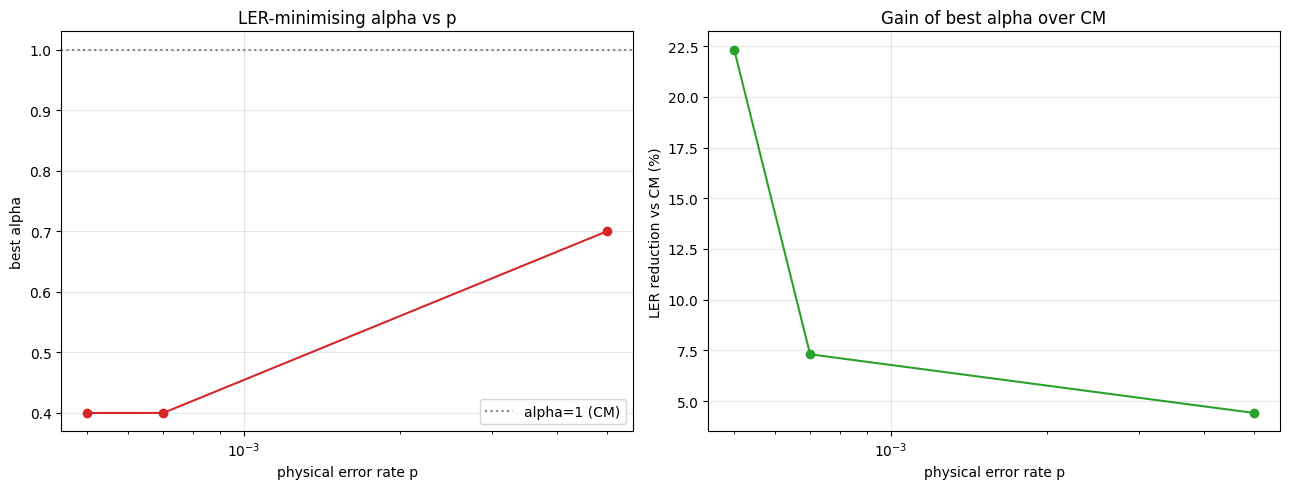

saved plots/pearl_alpha_best_vs_p_d7.png


In [ ]:
best_a = np.array([CFG["alpha_grid"][int(np.argmin(ler_grid[p]))] for p in CFG["p_values"]])
cm_ler_arr = np.array([cm_ler[p] for p in CFG["p_values"]])
best_ler = np.array([ler_grid[p].min() for p in CFG["p_values"]])
pv = np.array(CFG["p_values"])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(pv, best_a, "o-", color="#d62728")
ax[0].axhline(1.0, color="gray", ls=":", label="alpha=1 (CM)")
ax[0].set_xscale("log"); ax[0].set_xlabel("physical error rate p"); ax[0].set_ylabel("best alpha")
ax[0].set_title("LER-minimising alpha vs p"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(pv, 100 * (1 - best_ler / cm_ler_arr), "o-", color="#2ca02c")
ax[1].set_xscale("log"); ax[1].set_xlabel("physical error rate p")
ax[1].set_ylabel("LER reduction vs CM (%)")
ax[1].set_title("Gain of best alpha over CM"); ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(CFG["out_png_best"], dpi=200, bbox_inches="tight"); plt.show()
print("saved", CFG["out_png_best"])

### Notes
- **Reading it:** if every curve in panel 2 bottoms out at $\alpha=1$ (relative LER $=1$ is the
  minimum), CM is already optimal in this 1-parameter family. A minimum at $\alpha<1$ means the
  hard-evidence assumption over-trusts MWPM; $\alpha>1$ winning means an even stronger discount helps.
- **Statistics:** the apparent best-$\alpha$ is noisy when few errors are collected — check the gain in
  panel of section 3 against the binomial std in the CSV before trusting small differences. Increase
  `target_errors` / `max_shots` (low $p$ especially) for tighter curves.